# RMA Benchmark Analysis
## Lock/Unlock vs Fence vs PSCW vs SendRecv Performance Comparison
### Including Put and Get Operations

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

In [ ]:
def parse_benchmark_file(filename):
    """Parse Google Benchmark text output (handles ANSI color codes)"""
    results = []
    
    # Regex to remove ANSI escape codes
    ansi_escape = re.compile(r'\x1B(?:[@-Z\\-_]|\[[0-?]*[ -/]*[@-~])')
    
    with open(filename, 'r') as f:
        for line in f:
            # Strip ANSI color codes
            clean_line = ansi_escape.sub('', line)
            
            # Match benchmark lines
            match = re.search(
                r'benchmark_(\w+)/(\d+)/manual_time\s+([\d.]+)\s+us.*bytes_per_second=([\d.]+)(Mi|Gi)/s',
                clean_line
            )
            
            if match:
                operation_raw = match.group(1)
                # Convert snake_case to PascalCase and normalize names
                operation = operation_raw.replace('lock_unlock_put', 'LockUnlockPut') \
                                        .replace('lock_unlock_shared_get', 'LockUnlockSharedGet') \
                                        .replace('fence_put', 'FencePut') \
                                        .replace('pscw_put', 'PSCWPut') \
                                        .replace('pscw_get', 'PSCWGet') \
                                        .replace('sendrecv_comparison', 'SendRecv')
                
                msg_size = int(match.group(2))
                time_us = float(match.group(3))
                throughput = float(match.group(4))
                unit = match.group(5)
                
                # Convert to Gi/s
                throughput_gis = throughput / 1024.0 if unit == 'Mi' else throughput
                
                results.append({
                    'Operation': operation,
                    'MessageSize': msg_size,
                    'Time_us': time_us,
                    'Throughput_Gis': throughput_gis
                })
    
    return pd.DataFrame(results)

# Load your data
df = parse_benchmark_file('results.txt')

print(f"Loaded {len(df)} benchmarks")

Loaded 42 benchmarks
Operations: ['LockUnlockPut', 'LockUnlockSharedGet', 'FencePut', 'SendRecv', 'PSCWPut', 'PSCWGet']


In [168]:
df

,Operation,MessageSize,Time_us,Throughput_Gis
0,LockUnlockPut,1,2.350,0.003177
1,LockUnlockPut,8,2.490,0.023921
2,LockUnlockPut,64,2.440,0.195239
3,LockUnlockPut,512,2.510,1.518140
4,LockUnlockPut,4096,4.500,6.776160
5,LockUnlockPut,32768,18.400,13.266500
6,LockUnlockPut,262144,118.000,16.512900
7,LockUnlockSharedGet,1,2.730,0.002726
8,LockUnlockSharedGet,8,2.950,0.020200
9,LockUnlockSharedGet,64,2.690,0.177484


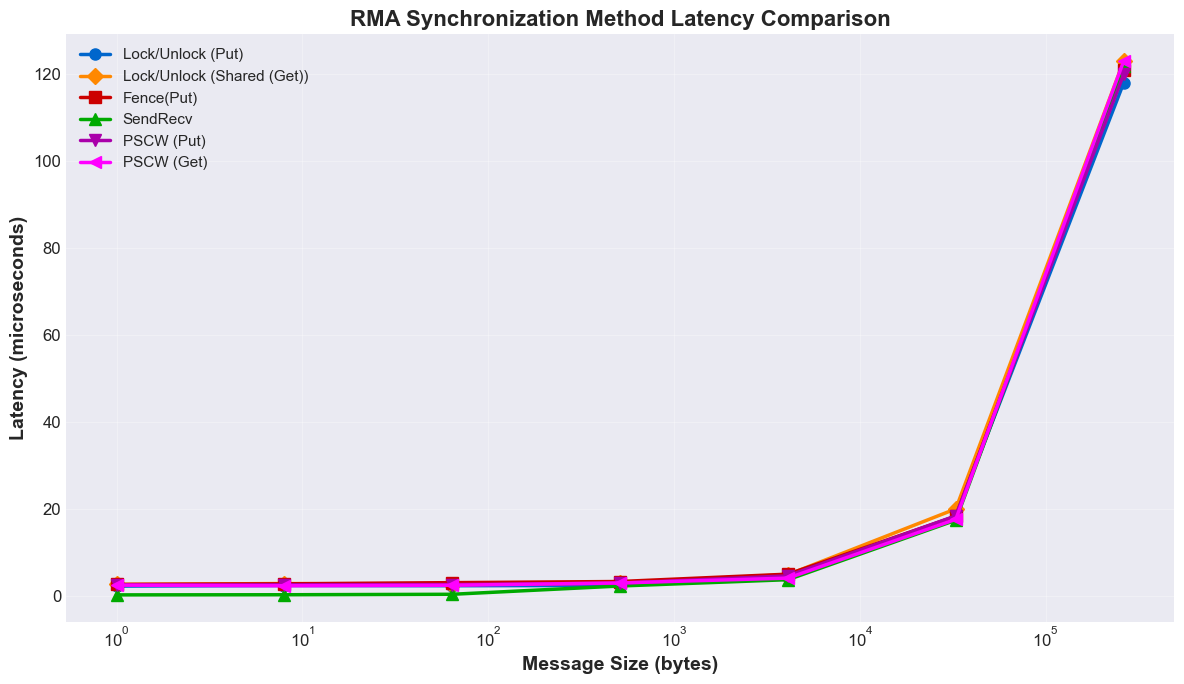

Graph saved as: latency_comparison.png


In [169]:
fig, ax = plt.subplots(figsize=(12, 7))

# Plot each operation
operations = df['Operation'].unique()
colors = {'LockUnlockPut': '#0066CC', 'FencePut': '#CC0000', 
          'SendRecv': '#00AA00', 'LockUnlockSharedGet': '#FF8800', 
          'PSCWPut': '#AA00AA', 'PSCWGet': '#FF00FF'}
markers = {'LockUnlockPut': 'o', 'FencePut': 's', 'SendRecv': '^', 
           'LockUnlockSharedGet': 'D', 'PSCWPut': 'v', 'PSCWGet': '<'}

for op in operations:
    data_subset = df[df['Operation'] == op]
    ax.plot(data_subset['MessageSize'], data_subset['Time_us'], 
            marker=markers.get(op, 'o'), linewidth=2.5, markersize=8,
            label=op.replace('LockUnlock', 'Lock/Unlock ').replace('Put', '(Put)').replace('SharedGet', '(Shared Get)').replace('PSCW', 'PSCW ').replace('Get', '(Get)'),
            color=colors.get(op, '#000000'))

ax.set_xscale('log')
ax.set_xlabel('Message Size (bytes)', fontsize=14, fontweight='bold')
ax.set_ylabel('Latency (microseconds)', fontsize=14, fontweight='bold')
ax.set_title('RMA Synchronization Method Latency Comparison', fontsize=16, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('latency_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Graph saved as: latency_comparison.png")

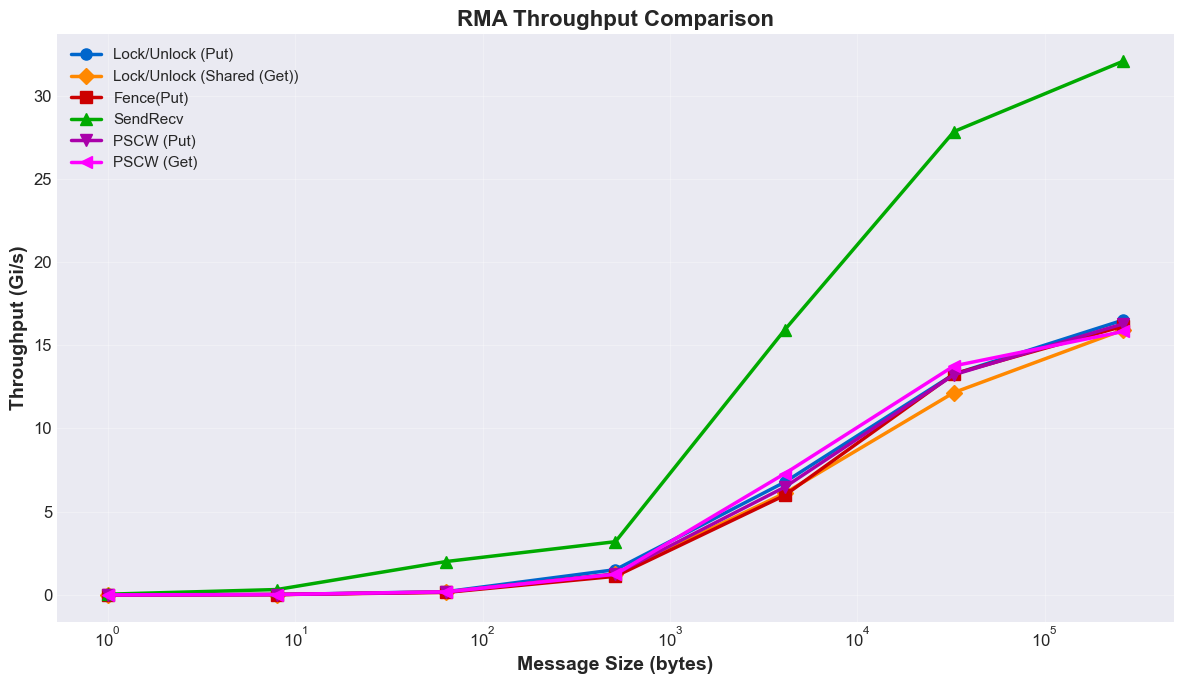

Graph saved as: throughput_comparison.png


In [170]:
fig, ax = plt.subplots(figsize=(12, 7))

for op in operations:
    data_subset = df[df['Operation'] == op]
    ax.plot(data_subset['MessageSize'], data_subset['Throughput_Gis'], 
            marker=markers.get(op, 'o'), linewidth=2.5, markersize=8,
            label=op.replace('LockUnlock', 'Lock/Unlock ').replace('Put', '(Put)').replace('SharedGet', '(Shared Get)').replace('PSCW', 'PSCW ').replace('Get', '(Get)'),
            color=colors.get(op, '#000000'))

ax.set_xscale('log')
ax.set_xlabel('Message Size (bytes)', fontsize=14, fontweight='bold')
ax.set_ylabel('Throughput (Gi/s)', fontsize=14, fontweight='bold')
ax.set_title('RMA Throughput Comparison', fontsize=16, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('throughput_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Graph saved as: throughput_comparison.png")

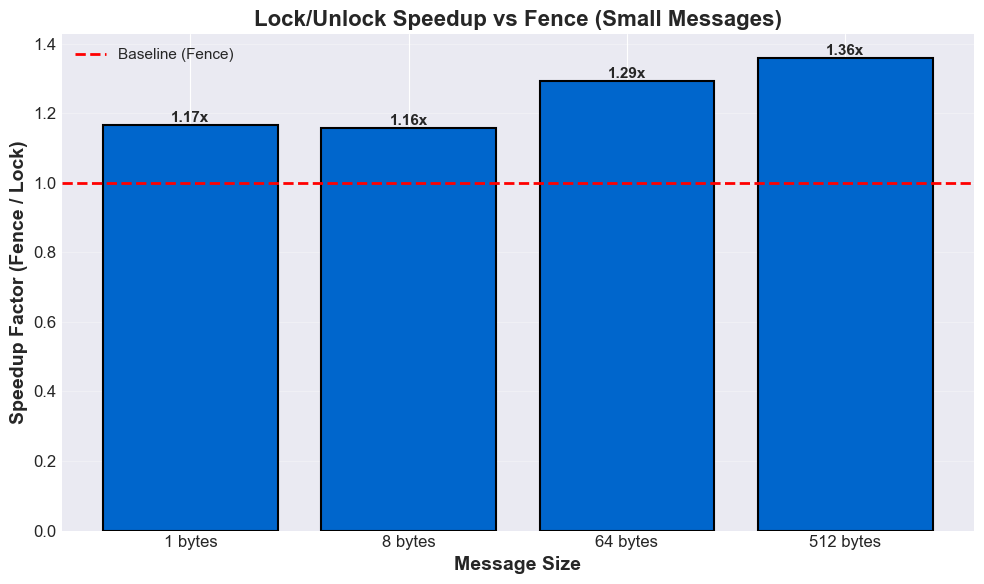

Graph saved as: speedup_comparison.png

Average speedup: 1.24x
Best speedup: 1.36x at 512 bytes


In [171]:
# Calculate speedup for small messages only
small_msg_sizes = [1, 8, 64, 512]

lock_data = df[df['Operation'] == 'LockUnlockPut']
fence_data = df[df['Operation'] == 'FencePut']

speedups = []
sizes = []

for size in small_msg_sizes:
    lock_time = lock_data[lock_data['MessageSize'] == size]['Time_us'].values[0]
    fence_time = fence_data[fence_data['MessageSize'] == size]['Time_us'].values[0]
    speedup = fence_time / lock_time
    speedups.append(speedup)
    sizes.append(size)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(range(len(sizes)), speedups, color='#0066CC', edgecolor='black', linewidth=1.5)
ax.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Baseline (Fence)')

ax.set_xticks(range(len(sizes)))
ax.set_xticklabels([f'{s} bytes' for s in sizes])
ax.set_ylabel('Speedup Factor (Fence / Lock)', fontsize=14, fontweight='bold')
ax.set_xlabel('Message Size', fontsize=14, fontweight='bold')
ax.set_title('Lock/Unlock Speedup vs Fence (Small Messages)', fontsize=16, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, speedup) in enumerate(zip(bars, speedups)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{speedup:.2f}x',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('speedup_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Graph saved as: speedup_comparison.png")
print(f"\nAverage speedup: {np.mean(speedups):.2f}x")
print(f"Best speedup: {max(speedups):.2f}x at {sizes[speedups.index(max(speedups))]} bytes")

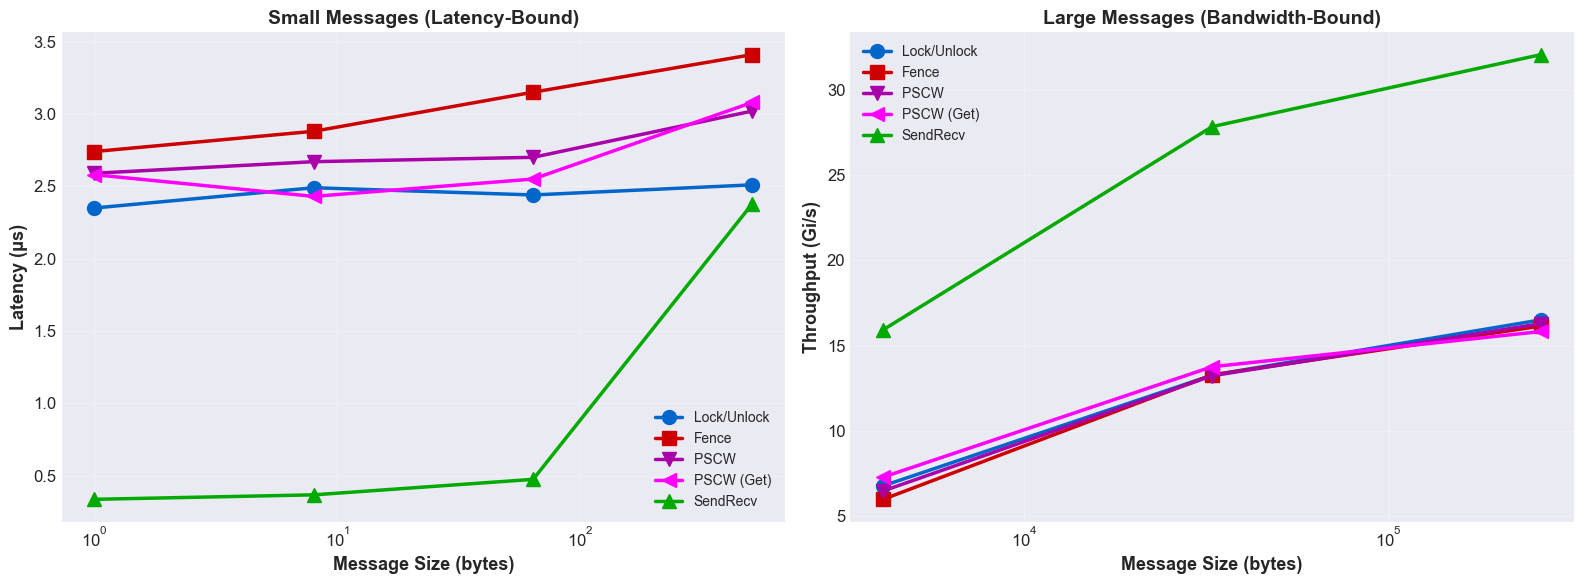

Graph saved as: small_vs_large_comparison.png


In [172]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Small messages (<=512 bytes)
small_sizes = [1, 8, 64, 512]
for op in ['LockUnlockPut', 'FencePut', 'PSCWPut', 'PSCWGet', 'SendRecv']:
    if op in df['Operation'].values:
        data_subset = df[(df['Operation'] == op) & (df['MessageSize'].isin(small_sizes))]
        ax1.plot(data_subset['MessageSize'], data_subset['Time_us'], 
                marker=markers.get(op, 'o'), linewidth=2.5, markersize=10,
                label=op.replace('LockUnlock', 'Lock/Unlock ').replace('Put', '').replace('PSCW', 'PSCW ').replace('Get', '(Get)'),
                color=colors.get(op, '#000000'))

ax1.set_xscale('log')
ax1.set_xlabel('Message Size (bytes)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Latency (μs)', fontsize=13, fontweight='bold')
ax1.set_title('Small Messages (Latency-Bound)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Large messages (>=4KB)
large_sizes = [4096, 32768, 262144]
for op in ['LockUnlockPut', 'FencePut', 'PSCWPut', 'PSCWGet', 'SendRecv']:
    if op in df['Operation'].values:
        data_subset = df[(df['Operation'] == op) & (df['MessageSize'].isin(large_sizes))]
        ax2.plot(data_subset['MessageSize'], data_subset['Throughput_Gis'], 
                marker=markers.get(op, 'o'), linewidth=2.5, markersize=10,
                label=op.replace('LockUnlock', 'Lock/Unlock ').replace('Put', '').replace('PSCW', 'PSCW ').replace('Get', '(Get)'),
                color=colors.get(op, '#000000'))

ax2.set_xscale('log')
ax2.set_xlabel('Message Size (bytes)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Throughput (Gi/s)', fontsize=13, fontweight='bold')
ax2.set_title('Large Messages (Bandwidth-Bound)', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('small_vs_large_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Graph saved as: small_vs_large_comparison.png")

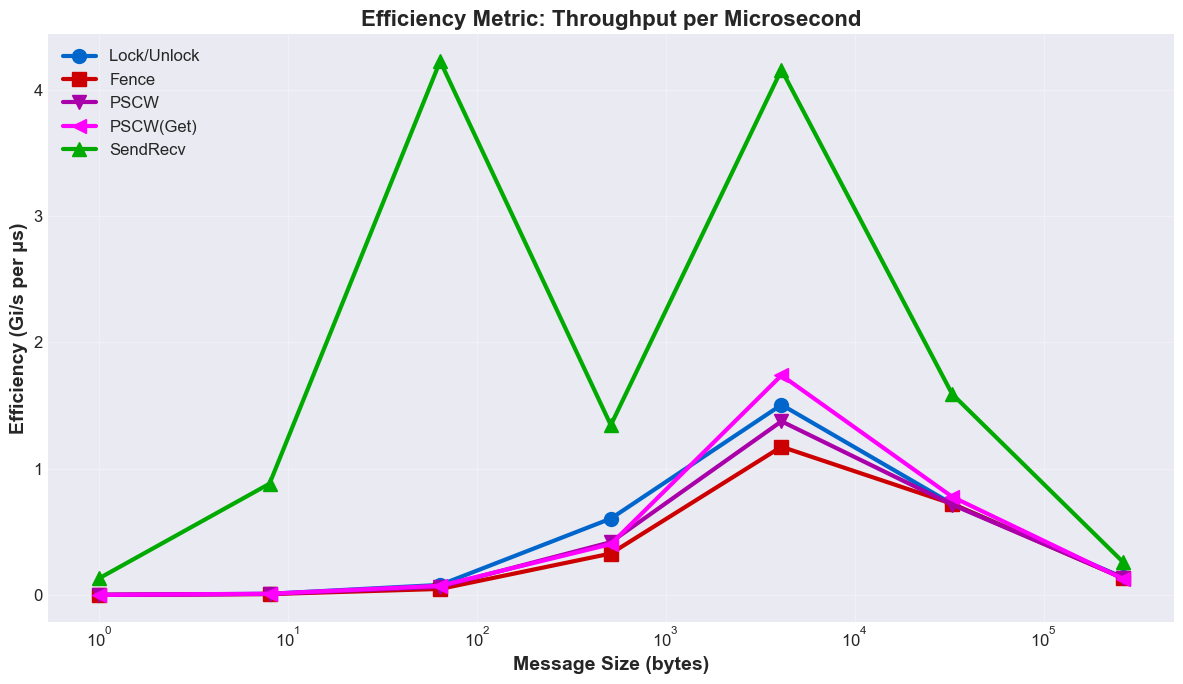

Graph saved as: efficiency_metric.png


In [174]:
# Calculate efficiency metric: throughput per unit time
fig, ax = plt.subplots(figsize=(12, 7))

for op in rma_ops:
    if op in df['Operation'].values:
        data_subset = df[df['Operation'] == op].copy()
        # Calculate efficiency: Gi/s per microsecond
        data_subset['Efficiency'] = data_subset['Throughput_Gis'] / data_subset['Time_us']

        ax.plot(data_subset['MessageSize'], data_subset['Efficiency'],
                marker=markers.get(op, 'o'), linewidth=3, markersize=10,
                label=op.replace('LockUnlock', 'Lock/Unlock ').replace('Put', '').replace('PSCW', 'PSCW').replace('Get', '(Get)'),
                color=colors.get(op, '#000000'))

ax.set_xscale('log')
ax.set_xlabel('Message Size (bytes)', fontsize=14, fontweight='bold')
ax.set_ylabel('Efficiency (Gi/s per μs)', fontsize=14, fontweight='bold')
ax.set_title('Efficiency Metric: Throughput per Microsecond', fontsize=16, fontweight='bold')
ax.legend(fontsize=12, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('efficiency_metric.png', dpi=300, bbox_inches='tight')
plt.show()

print("Graph saved as: efficiency_metric.png")

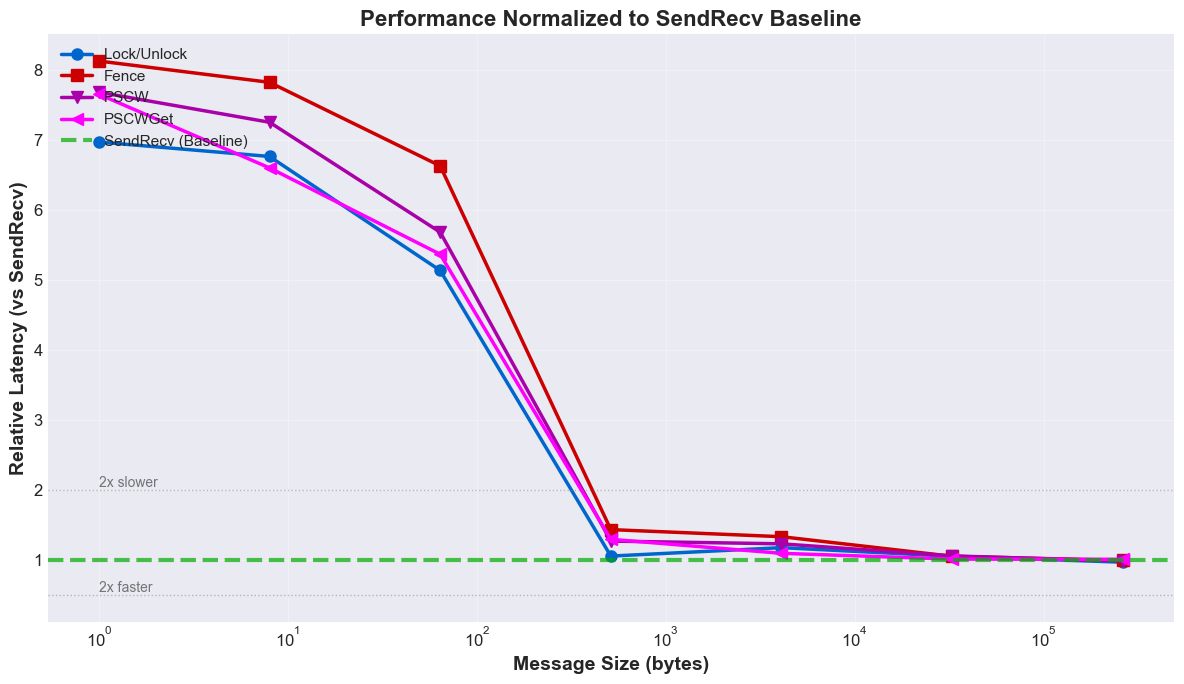

Graph saved as: normalized_performance.png


In [176]:
# Normalize latency relative to SendRecv (baseline)
sendrecv_data = df[df['Operation'] == 'SendRecv'][['MessageSize', 'Time_us']].rename(columns={'Time_us': 'SendRecv_Time'})
normalized_df = df.merge(sendrecv_data, on='MessageSize')
normalized_df['Relative_Latency'] = normalized_df['Time_us'] / normalized_df['SendRecv_Time']

fig, ax = plt.subplots(figsize=(12, 7))

for op in rma_ops:
    if op != 'SendRecv':
        data_subset = normalized_df[normalized_df['Operation'] == op]
        ax.plot(data_subset['MessageSize'], data_subset['Relative_Latency'], 
                marker=markers.get(op, 'o'), linewidth=2.5, markersize=8,
                label=op.replace('LockUnlock', 'Lock/Unlock ').replace('Put', '').replace('PSCW', 'PSCW'),
                color=colors.get(op, '#000000'))

ax.axhline(y=1.0, color='#00AA00', linestyle='--', linewidth=3, label='SendRecv (Baseline)', alpha=0.7)
ax.set_xscale('log')
ax.set_xlabel('Message Size (bytes)', fontsize=14, fontweight='bold')
ax.set_ylabel('Relative Latency (vs SendRecv)', fontsize=14, fontweight='bold')
ax.set_title('Performance Normalized to SendRecv Baseline', fontsize=16, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)

# Add reference lines
ax.axhline(y=0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax.axhline(y=2.0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax.text(1, 0.5, '2x faster', fontsize=10, alpha=0.6, va='bottom')
ax.text(1, 2.0, '2x slower', fontsize=10, alpha=0.6, va='bottom')

plt.tight_layout()
plt.savefig('normalized_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("Graph saved as: normalized_performance.png")